# Marker positivity

Reproduces the **marker-positivity (MP)** decision-quality panels of the DeepCell Types paper. Marker positivity asks, per cell and per protein marker, whether that marker is expressed — a binary call the FiLM-conditioned MP head produces from the shared cell embedding, closed at a learned per-marker threshold τ.

Panels, in order:

- **Headline MP comparison vs Nimbus** (`mp_summary_comparison`, Fig. 3d) and the **per-marker F1 waterfall** (`mp_per_marker_waterfall`, Supp. Fig. 7a) on the held-out test split.
- **FiLM MP decision curves** for CD45 / CD206 / SMA (Supp. Fig. 7c–e) and the **learned per-marker threshold histogram** (Supp. Fig. 7b).

All figures use a consistent publication figure style via `dct_figures.style`. DCT MP calls use the released From Scratch predictions; Nimbus is the published baseline at τ=0.5.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, json
from dct_figures import paths, style, colors
style.apply_style()

## Shared inputs

All MP inputs live under `paths.OUTPUT`. The gold-standard JSONs cover the DeepCell Types predictions and the Nimbus baseline.

In [2]:
from dct_figures.style import (PAL, COL_2, COL_1_5, COL_1, BAR_WIDTH,
    FS_BODY, FS_TICK,
    FS_SMALL, FS_TINY, PERF_BAR_INCHES, PERF_BAR_PITCH_INCHES,
    setup_perf_bar_axes)
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# Released From Scratch predictions under paths.OUTPUT.
MP_PER_MARKER = paths.OUTPUT / 'deepcelltypes_mp_per_marker.csv'
OURS_GOLD     = paths.OUTPUT / 'deepcelltypes_gold_metrics.json'
NIMBUS_GOLD   = paths.OUTPUT / 'nimbus_gold_metrics.json'
OURS_ALL      = paths.OUTPUT / 'deepcelltypes_mp_all_datasets.json'
NIMBUS_ALL    = paths.OUTPUT / 'nimbus_all_mp_nimbus_metrics.json'
TEST_MP_PREDS = paths.OUTPUT / 'deepcelltypes_test_mp_preds.csv'
THRESHOLDS    = paths.OUTPUT / 'deepcelltypes_mp_thresholds.json'
for p in (MP_PER_MARKER, OURS_GOLD, NIMBUS_GOLD, OURS_ALL, NIMBUS_ALL,
          TEST_MP_PREDS, THRESHOLDS):
    paths.need(p)
print('all MP inputs present')

all MP inputs present


## Headline MP comparison vs Nimbus — Fig. 3d

_Caption:_ Headline marker-positivity macro/weighted metrics across methods. Macro F1 for DCT (Ours) vs Nimbus in two settings: the Pan-Multiplex Gold Standard and the all-datasets evaluation.

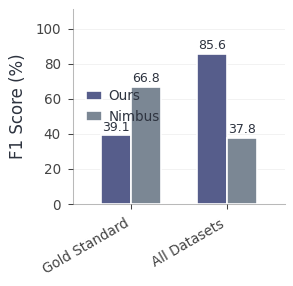

In [3]:
ours_gold = json.load(open(OURS_GOLD))
nimbus_gold = json.load(open(NIMBUS_GOLD))
ours_all = json.load(open(OURS_ALL))
nimbus_all = json.load(open(NIMBUS_ALL))

settings = ['Gold Standard', 'All Datasets']
ours_vals = [ours_gold['macro_f1'] * 100,
             ours_all['metrics']['mp_macro_f1'] * 100]
nimbus_all_pm = nimbus_all['per_marker']
nimbus_all_macro = float(np.mean([v['f1'] for v in nimbus_all_pm.values()]) * 100)
nimbus_vals = [nimbus_gold['macro_f1'] * 100, nimbus_all_macro]

fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
x, w = setup_perf_bar_axes(fig, ax, len(settings),
                           target_bar_inches=PERF_BAR_INCHES,
                           target_pitch_inches=2 * PERF_BAR_PITCH_INCHES)
b1 = ax.bar(x - w / 2, ours_vals, w, color=PAL['theme'], label='Ours',
            edgecolor='white', linewidth=0.8, zorder=3)
b2 = ax.bar(x + w / 2, nimbus_vals, w, color=PAL['gray'], label='Nimbus',
            edgecolor='white', linewidth=0.8, zorder=3)
ax.set_ylabel('F1 Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(settings, fontsize=FS_TICK, rotation=30, ha='right')
top = max(max(ours_vals), max(nimbus_vals))
ax.set_ylim(0, top * 1.30)
ax.legend(fontsize=FS_TICK, loc='center left', frameon=False,
          handlelength=1.2, columnspacing=1.2)
style.style_ax(ax)
style.add_value_labels(ax, b1, fmt='{:.1f}', fontsize=FS_SMALL, offset=1)
style.add_value_labels(ax, b2, fmt='{:.1f}', fontsize=FS_SMALL, offset=1)
plt.show()

## Per-marker F1 waterfall — Supp. Fig. 7a

_Caption:_ Per-marker F1 waterfall for From Scratch on the held-out test split (markers with F1=0 omitted). Bars sorted by F1 descending and color-tiered (≥90 / 80–89 / 60–79 / 40–59 / <40 %); the corner chip reports the macro F1 over the plotted markers.

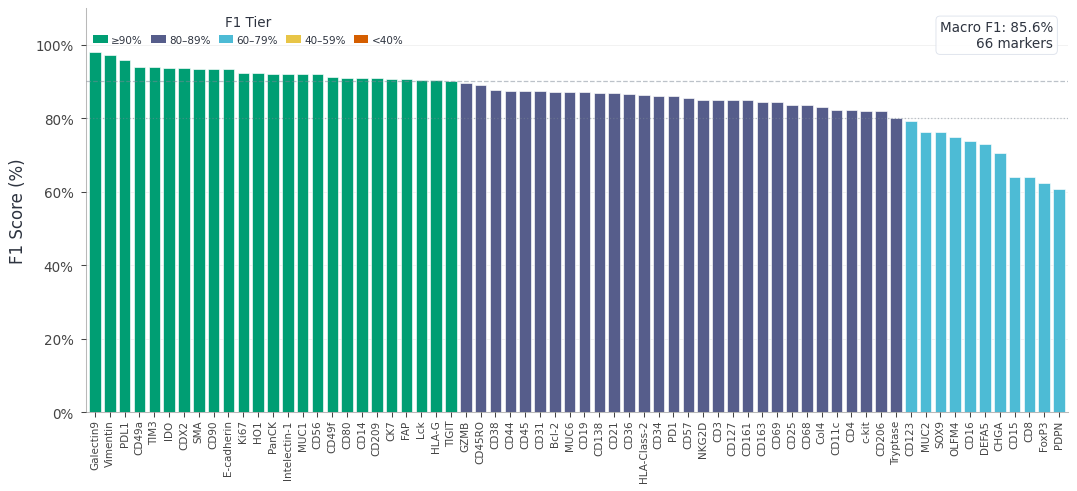

In [4]:
df = pd.read_csv(MP_PER_MARKER)
df = df[df['f1'] > 0].sort_values('f1', ascending=False).reset_index(drop=True)
n = len(df)
fig, ax = plt.subplots(figsize=(COL_2, 3.4))
wcolors = []
for f1 in df['f1']:
    if f1 >= 0.9: wcolors.append(PAL['green'])
    elif f1 >= 0.8: wcolors.append(PAL['blue'])
    elif f1 >= 0.6: wcolors.append(PAL['teal'])
    elif f1 >= 0.4: wcolors.append(PAL['yellow'])
    else: wcolors.append(PAL['red'])
ax.bar(range(n), df['f1'] * 100, color=wcolors, width=BAR_WIDTH,
       edgecolor='white', linewidth=0.3)
ax.set_xticks(range(n))
ax.set_xticklabels(df['marker'], rotation=90, ha='center', fontsize=FS_TINY)
ax.tick_params(axis='x', pad=1)
ax.set_xlim(-0.6, n - 0.4)
ax.set_ylabel('F1 Score (%)')
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
style.style_ax(ax)
for y, ls in [(90, '--'), (80, ':')]:
    ax.axhline(y, color=PAL['gray'], linestyle=ls, linewidth=0.6, alpha=0.5)
legend_items = [Patch(facecolor=PAL['green'], label='\u226590%'),
                Patch(facecolor=PAL['blue'], label='80\u201389%'),
                Patch(facecolor=PAL['teal'], label='60\u201379%'),
                Patch(facecolor=PAL['yellow'], label='40\u201359%'),
                Patch(facecolor=PAL['red'], label='<40%')]
ax.legend(handles=legend_items, loc='upper left', title='F1 Tier',
          fontsize=FS_TINY, title_fontsize=FS_TICK, ncol=5,
          handletextpad=0.3, columnspacing=0.8, borderaxespad=0.3)
macro_f1 = df['f1'].mean() * 100
ax.text(0.985, 0.97, f'Macro F1: {macro_f1:.1f}%\n{n} markers',
        transform=ax.transAxes, ha='right', va='top', fontsize=FS_TICK,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=PAL['light_gray'], alpha=0.9))
fig.tight_layout()
plt.show()

## FiLM MP decision curves — Supp. Fig. 7c–e

For CD45 (pan-immune), CD206 (macrophage subset) and SMA (smooth muscle): the predicted MP-probability distribution for GT positives vs negatives on the held-out test split, with the learned threshold τ marked. The spread of τ away from 0.5 is direct evidence the FiLM head produces marker-specific decision functions.

In [5]:
MARKERS = [('CD45', 'Pan immune'), ('CD206', 'Macrophage subset'),
           ('SMA', 'Smooth muscle')]
th = json.load(open(THRESHOLDS))
td = pd.read_csv(TEST_MP_PREDS)

def _load_marker_test(marker):
    j = td[td.channel == marker][['fov', 'cell_id', 'activity', 'pred_score']].copy()
    return j[j.activity.isin([0, 1])].reset_index(drop=True)

def _decision_panel(marker, subtitle):
    j = _load_marker_test(marker)
    tau = float(th.get(marker, 0.5))
    pos = j.loc[j.activity == 1, 'pred_score'].to_numpy()
    neg = j.loc[j.activity == 0, 'pred_score'].to_numpy()
    bins = np.linspace(0.0, 1.0, 41)
    fig, ax = plt.subplots(figsize=(COL_1, 2.6))
    ax.hist(neg, bins=bins, color=PAL['theme_light'], alpha=0.85,
            edgecolor='white', linewidth=0.3,
            label=f'GT negative (n={len(neg):,})', zorder=2)
    ax.hist(pos, bins=bins, color=PAL['red'], alpha=0.75,
            edgecolor='white', linewidth=0.3,
            label=f'GT positive (n={len(pos):,})', zorder=3)
    ax.axvline(tau, color=PAL['dark'], linestyle='--', linewidth=1.0, zorder=4)
    ax.text(tau, 0.55, f' \u03c4 = {tau:.2f}', ha='left', va='center',
            fontsize=7.0, color=PAL['dark'],
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor=PAL['light_gray'], linewidth=0.4, alpha=0.92))
    ax.set_xlim(0, 1); ax.set_yscale('log')
    ax.set_xlabel('Predicted MP probability'); ax.set_ylabel('Cells (log)')
    ax.set_title(f'{marker} \u2014 {subtitle}', fontsize=FS_BODY)
    ax.legend(loc='upper center', fontsize=6.8, framealpha=0.92,
              handletextpad=0.5, borderaxespad=0.4)
    style.style_ax(ax, grid_axis='y')
    fig.tight_layout()
    plt.show()
    print(f'  {marker}: {len(j):,} cells (pos {(j.activity==1).sum():,}, '
          f'neg {(j.activity==0).sum():,}), \u03c4={tau:.2f}')

panel_taus = {m: float(th.get(m, 0.5)) for m, _ in MARKERS}

### CD45 (pan-immune)

_Caption:_ FiLM MP decision curve — CD45 (pan-immune).

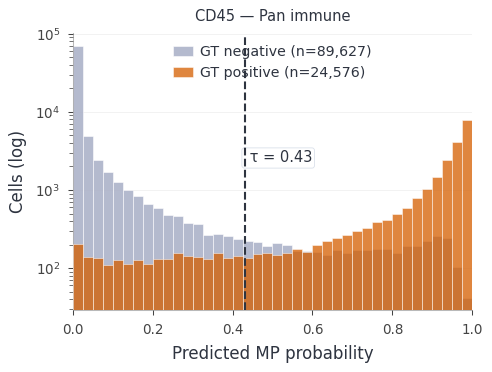

  CD45: 114,203 cells (pos 24,576, neg 89,627), τ=0.43


In [6]:
_decision_panel('CD45', 'Pan immune')

### CD206 (macrophage subset)

_Caption:_ FiLM MP decision curve — CD206 (macrophage subset).

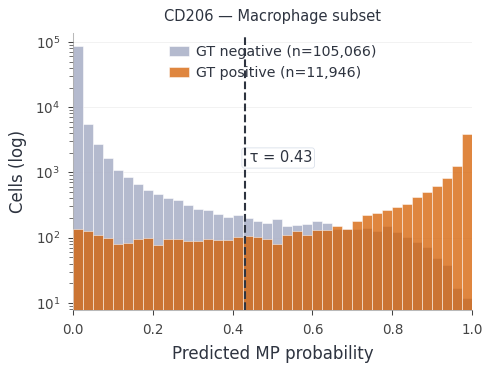

  CD206: 117,012 cells (pos 11,946, neg 105,066), τ=0.43


In [7]:
_decision_panel('CD206', 'Macrophage subset')

### SMA (smooth muscle)

_Caption:_ FiLM MP decision curve — SMA (smooth muscle).

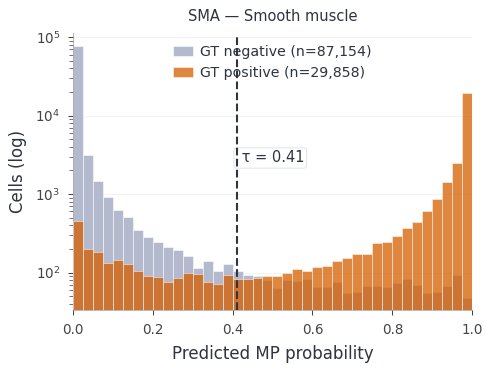

  SMA: 117,012 cells (pos 29,858, neg 87,154), τ=0.41


In [8]:
_decision_panel('SMA', 'Smooth muscle')

## Learned per-marker thresholds — Supp. Fig. 7b

_Caption:_ Histogram of learned per-marker thresholds τ swept on the train split. The three decision-curve markers are tagged; the spread around the default 0.5 quantifies the marker-specific operating points.

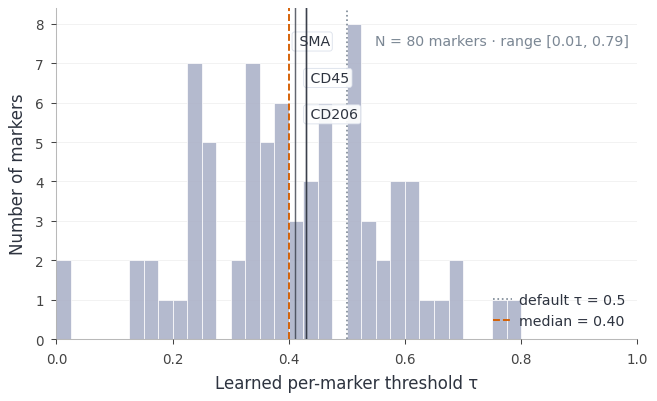

In [9]:
vals = np.array(list(th.values()), dtype=float)
bins = np.arange(0.0, 1.005, 0.025)
fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
ax.hist(vals, bins=bins, color=PAL['theme_light'], edgecolor='white',
        linewidth=0.4, alpha=0.85, zorder=2)
ax.axvline(0.5, color=PAL['gray'], linestyle=':', linewidth=0.8,
           label='default \u03c4 = 0.5', zorder=3)
median = float(np.median(vals))
ax.axvline(median, color=PAL['red'], linestyle='--', linewidth=0.9,
           label=f'median = {median:.2f}', zorder=3)
for i, (marker, tau) in enumerate(sorted(panel_taus.items(), key=lambda kv: kv[1])):
    ax.axvline(tau, color=PAL['dark'], linewidth=0.7, alpha=0.75, zorder=4)
    ax.text(tau, 0.92 - 0.11 * i, f' {marker}', ha='left', va='top',
            fontsize=6.8, color=PAL['dark'],
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor=PAL['light_gray'], linewidth=0.4, alpha=0.92))
ax.text(0.985, 0.92,
        f'N = {len(vals)} markers \u00b7 range '
        f'[{vals.min():.2f}, {vals.max():.2f}]',
        transform=ax.transAxes, ha='right', va='top', fontsize=6.8,
        color=PAL['gray'])
ax.set_xlim(0, 1)
ax.set_xlabel('Learned per-marker threshold \u03c4')
ax.set_ylabel('Number of markers')
ax.legend(loc='lower right', fontsize=6.8, framealpha=0.92,
          handletextpad=0.5, borderaxespad=0.4)
style.style_ax(ax, grid_axis='y')
fig.tight_layout()
plt.show()